# 🛰️ OrbitFood — Previsão de Insegurança Alimentar com Dados Espaciais
**Grupo:** Data Travelers  
**Disciplina:** Global Solution 2026 — FIAP  
**Tema:** Data Science, inovação e tecnologia reinventando a forma de explorar o espaço e transformar a vida na Terra

---

## 1. Descrição do Problema

# Contexto

Apesar de o Brasil estar entre os maiores produtores e exportadores de alimentos do mundo, a insegurança alimentar ainda é uma realidade para milhões de pessoas. De acordo com a Rede PENSSAN (2022), aproximadamente 33 milhões de brasileiros enfrentam dificuldades no acesso regular à alimentação.

Esse cenário não está relacionado apenas à quantidade de alimentos produzidos, mas também a fatores como desigualdade social, distribuição inadequada de recursos e dificuldades de monitoramento em regiões mais vulneráveis.

Municípios com menos de 50 mil habitantes costumam ser os mais afetados, pois possuem menor capacidade técnica e orçamentária para identificar riscos e agir preventivamente diante de possíveis crises alimentares.

## Problema a ser resolvido

Como identificar, com até 60 dias de antecedência, os municípios brasileiros com maior risco de insegurança alimentar utilizando dados de satélite e indicadores socioeconômicos?

## Por que esse problema é relevante?

- Grande parte das ações de assistência ocorre apenas quando a situação já se agravou;
- Informações agrícolas e sociais estão disponíveis, mas frequentemente se encontram dispersas em diferentes bases de dados;
- A antecipação de cenários de risco pode auxiliar gestores públicos na tomada de decisões mais rápidas e eficientes.

## Quem é impactado?

- Secretarias municipais de agricultura e assistência social;
- Pequenos produtores rurais e cooperativas;
- Órgãos responsáveis por programas sociais;
- Populações em situação de vulnerabilidade alimentar.

## Como os dados ajudam na tomada de decisão?

Dados obtidos por satélites permitem acompanhar indicadores como vegetação (NDVI), temperatura, precipitação e uso do solo. Ao combinar essas informações com dados socioeconômicos municipais, como IDH, renda e histórico de produção agrícola, é possível desenvolver modelos preditivos capazes de identificar regiões com maior risco de insegurança alimentar antes que o problema se torne crítico.

## Conexão com o Global Solution

Este projeto demonstra como a integração entre dados geoespaciais e análise de dados pode apoiar a formulação de políticas públicas e ações preventivas voltadas à segurança alimentar. A proposta está alinhada aos Objetivos de Desenvolvimento Sustentável (ODS) da ONU, especialmente ODS 2 (Fome Zero), ODS 10 (Redução das Desigualdades) e ODS 13 (Ação Contra a Mudança Global do Clima).

---
## 2. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

# Estilo visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#0D9488', '#103556', '#16A34A', '#84CC16', '#94A3B8']
print('✅ Bibliotecas importadas com sucesso.')

✅ Bibliotecas importadas com sucesso.


---
## 3. Carregamento e Descrição do Dataset

### Fontes de dados utilizadas
| Variável | Fonte | Descrição |
|---|---|---|
| `ndvi_variacao_90d` | MapBiomas / NASA EarthData | Variação do índice de vegetação nos últimos 90 dias |
| `dias_sem_chuva` | NOAA / INMET | Dias consecutivos sem precipitação significativa |
| `temp_anomalia` | NASA EarthData | Desvio de temperatura em relação à média histórica (°C) |
| `producao_agricola_var` | IBGE PAM | Variação da produção agrícola municipal ano a ano (%) |
| `idh_municipal` | IBGE / PNUD | Índice de Desenvolvimento Humano do município |
| `renda_per_capita` | IBGE Censo 2022 | Renda média domiciliar per capita (R$) |
| `distancia_polo_km` | IBGE / IPEA | Distância até o polo distribuidor mais próximo (km) |
| `bioma` | IBGE / MapBiomas | Bioma predominante do município |
| `pop_vulneravel_pct` | IBGE / MDS | % da população em situação de vulnerabilidade social |
| `risco_alimentar` | **Variável-alvo** | Baixo / Médio / Alto risco de insegurança alimentar |

> **Nota:** O dataset abaixo é simulado para fins de prototipagem acadêmica, construído com distribuições estatísticas compatíveis com os dados reais das fontes citadas. Em um ambiente de produção, os dados seriam obtidos diretamente via API das fontes listadas acima.

In [2]:
np.random.seed(42)
N = 1200  # municípios simulados

biomas = ['Amazônia', 'Cerrado', 'Caatinga', 'Mata Atlântica', 'Pampa', 'Pantanal']
bioma_pesos = [0.30, 0.24, 0.20, 0.15, 0.06, 0.05]

# ── Variáveis independentes ──────────────────────────────────────────
ndvi_var       = np.random.normal(-0.08, 0.15, N).clip(-0.5, 0.3)
dias_sem_chuva = np.random.gamma(shape=2.5, scale=12, size=N).astype(int).clip(0, 120)
temp_anomalia  = np.random.normal(1.2, 1.5, N).clip(-3, 6)
prod_var       = np.random.normal(-5, 20, N).clip(-60, 50)
idh            = np.random.beta(5, 3, N).clip(0.4, 0.9)
renda_pc       = np.random.lognormal(6.5, 0.6, N).clip(300, 5000)
dist_polo      = np.random.exponential(80, N).clip(5, 500)
bioma_col      = np.random.choice(biomas, N, p=bioma_pesos)
pop_vuln       = np.random.beta(2, 5, N).clip(0.05, 0.70)

# ── Variável-alvo: score de risco ────────────────────────────────────
score = (
    -ndvi_var * 3.0           +  # NDVI caindo → mais risco
    dias_sem_chuva * 0.025    +  # seca → mais risco
    temp_anomalia * 0.20      +  # calor anômalo → mais risco
    -prod_var * 0.015         +  # queda de produção → mais risco
    -idh * 4.0                +  # baixo IDH → mais risco
    -np.log1p(renda_pc)*0.3   +  # baixa renda → mais risco
    dist_polo * 0.004         +  # longe de polo → mais risco
    pop_vuln * 3.5            +  # mais vulneráveis → mais risco
    np.random.normal(0, 0.4, N)  # ruído
)

# ── Converter score em classe ────────────────────────────────────────
p33, p66 = np.percentile(score, [33, 66])
risco = np.where(score < p33, 'Baixo', np.where(score < p66, 'Médio', 'Alto'))

df = pd.DataFrame({
    'ndvi_variacao_90d':    ndvi_var,
    'dias_sem_chuva':       dias_sem_chuva,
    'temp_anomalia':        temp_anomalia,
    'producao_agricola_var': prod_var,
    'idh_municipal':        idh,
    'renda_per_capita':     renda_pc,
    'distancia_polo_km':    dist_polo,
    'bioma':                bioma_col,
    'pop_vulneravel_pct':   pop_vuln,
    'risco_alimentar':      risco
})

print(f'Dataset gerado: {df.shape[0]} municípios × {df.shape[1]} variáveis')
print(f"\nDistribuição das classes:\n{df['risco_alimentar'].value_counts()}")
df.head(8)

Dataset gerado: 1200 municípios × 10 variáveis

Distribuição das classes:
risco_alimentar
Alto     408
Médio    396
Baixo    396
Name: count, dtype: int64


,ndvi_variacao_90d,dias_sem_chuva,temp_anomalia,producao_agricola_var,idh_municipal,renda_per_capita,distancia_polo_km,bioma,pop_vulneravel_pct,risco_alimentar
0,-0.005493,28,1.089041,5.915734,0.647945,713.367739,401.181768,Caatinga,0.106149,Alto
1,-0.100740,19,1.086502,-48.431428,0.869241,809.173761,7.253391,Amazônia,0.409500,Médio
2,0.017153,26,4.158813,-5.162264,0.699058,316.880634,158.586132,Mata Atlântica,0.119215,Médio
3,0.148454,26,-0.878982,-1.838215,0.726660,1401.706336,39.611367,Pampa,0.483722,Baixo
4,-0.115123,8,1.958384,-10.550885,0.851966,1186.708315,59.399171,Mata Atlântica,0.283246,Baixo
5,-0.115121,70,3.433670,20.825477,0.563954,556.706981,197.035310,Cerrado,0.494467,Alto
6,0.156882,9,4.607175,3.435601,0.400000,1127.412330,290.084980,Caatinga,0.550758,Alto
7,0.035115,15,0.593404,21.203838,0.520953,2208.024491,24.322686,Pampa,0.238197,Baixo


---
## 4. Análise Exploratória dos Dados (EDA)

In [3]:
print('=== Estatísticas descritivas ===')
df.describe().round(3)

=== Estatísticas descritivas ===


,ndvi_variacao_90d,dias_sem_chuva,temp_anomalia,producao_agricola_var,idh_municipal,renda_per_capita,distancia_polo_km,pop_vulneravel_pct
count,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000
mean,-0.074,29.813,1.138,-5.591,0.627,796.233,79.612,0.285
std,0.147,18.694,1.497,19.736,0.146,510.960,77.950,0.153
min,-0.500,1.000,-3.000,-60.000,0.400,300.000,5.000,0.050
25%,-0.174,16.000,0.127,-18.250,0.510,437.368,23.811,0.164
50%,-0.073,26.000,1.150,-5.497,0.628,660.371,56.259,0.267
75%,0.021,39.000,2.097,7.726,0.743,971.159,111.404,0.381
max,0.300,120.000,6.000,50.000,0.900,4281.380,500.000,0.700


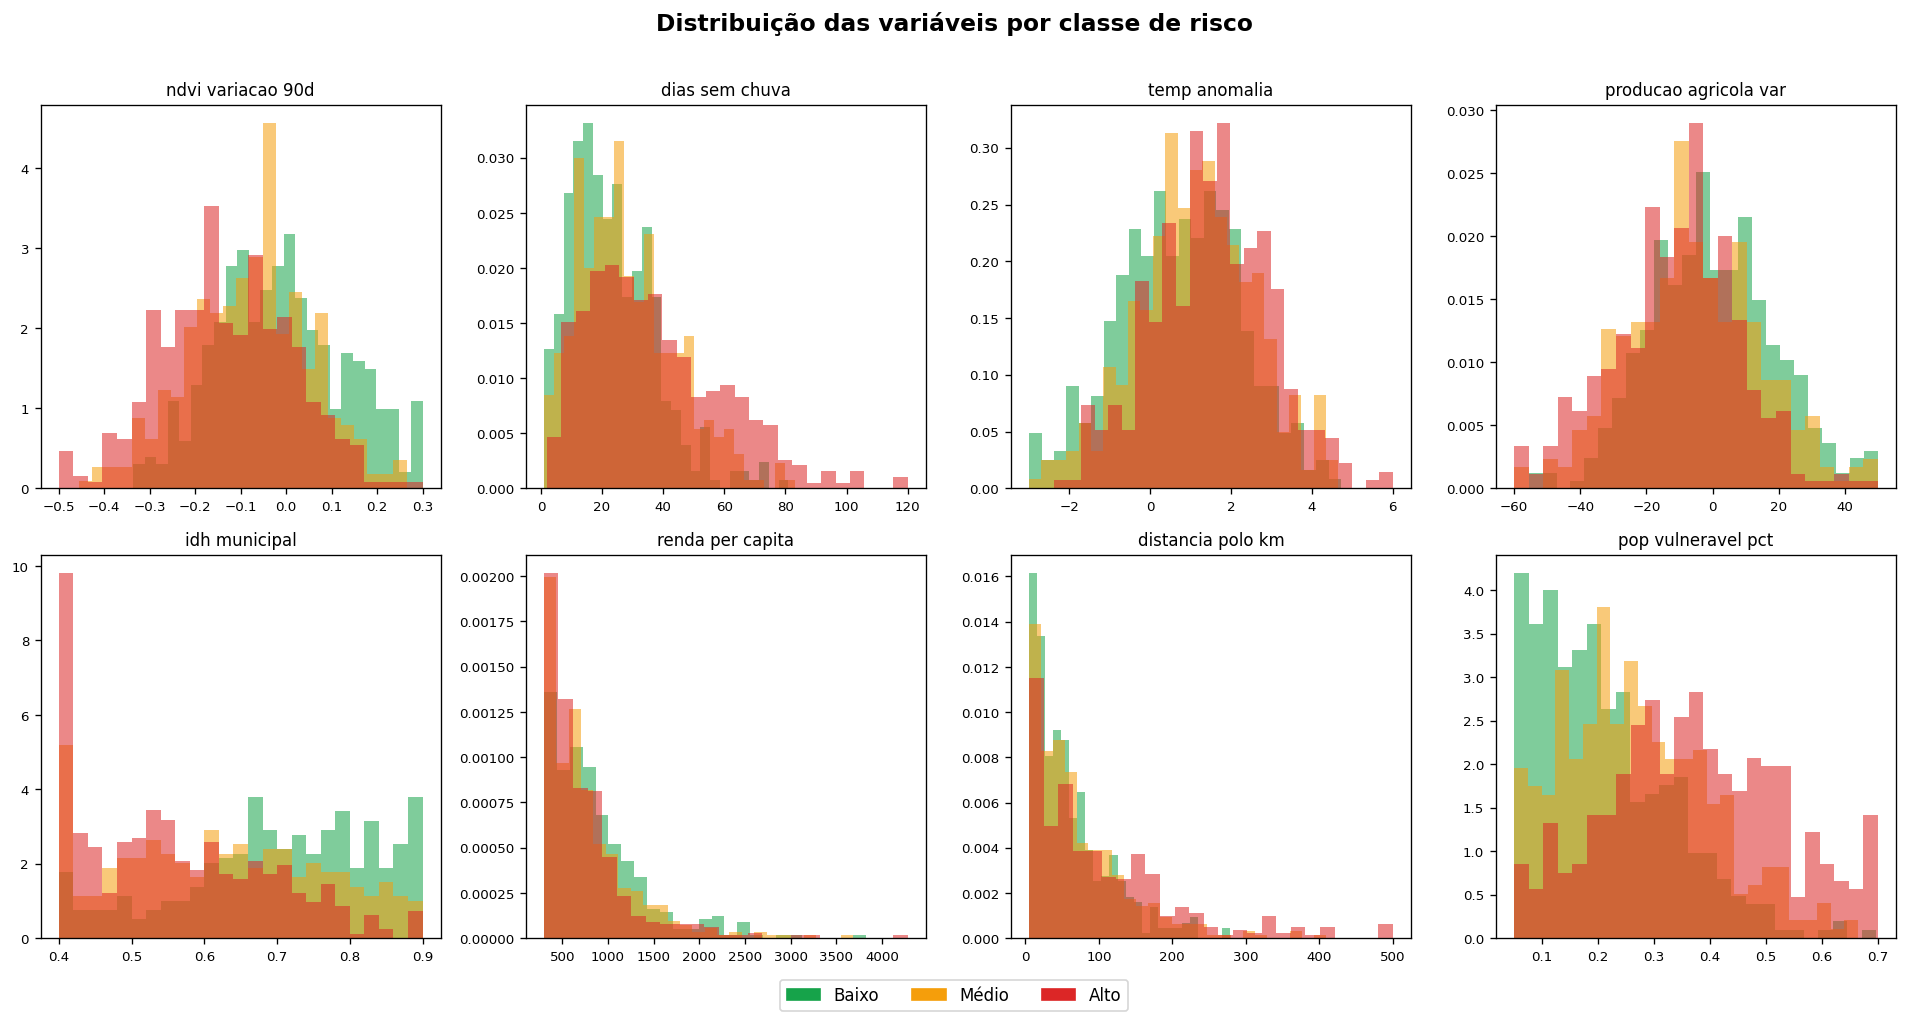

📊 EDA concluída.


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribuição das variáveis por classe de risco', fontsize=14, fontweight='bold', y=1.01)

num_cols = ['ndvi_variacao_90d', 'dias_sem_chuva', 'temp_anomalia',
            'producao_agricola_var', 'idh_municipal', 'renda_per_capita',
            'distancia_polo_km', 'pop_vulneravel_pct']

palette = {'Baixo': '#16A34A', 'Médio': '#F59E0B', 'Alto': '#DC2626'}

for ax, col in zip(axes.flatten(), num_cols):
    for classe, cor in palette.items():
        subset = df[df['risco_alimentar'] == classe][col]
        ax.hist(subset, bins=25, alpha=0.55, color=cor, label=classe, density=True)
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

handles = [mpatches.Patch(color=cor, label=cls) for cls, cor in palette.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('eda_distribuicoes.png', bbox_inches='tight')
plt.show()
print('📊 EDA concluída.')

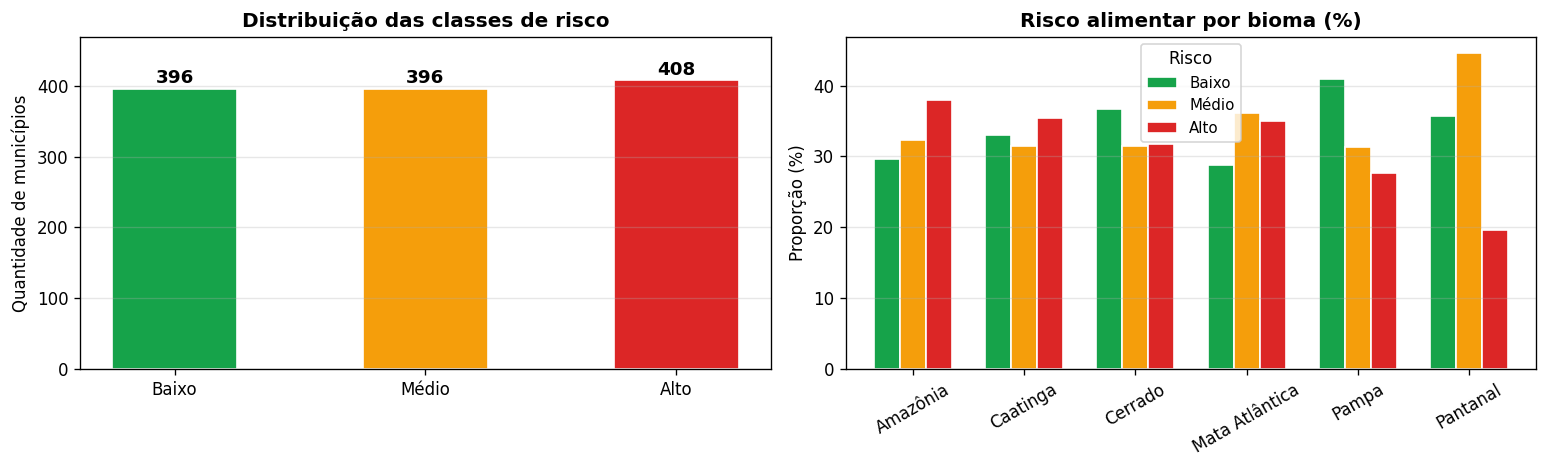

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição de classes
counts = df['risco_alimentar'].value_counts().reindex(['Baixo', 'Médio', 'Alto'])
bars = ax1.bar(counts.index, counts.values, color=['#16A34A', '#F59E0B', '#DC2626'], width=0.5, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(bar.get_height()), ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Distribuição das classes de risco', fontweight='bold')
ax1.set_ylabel('Quantidade de municípios')
ax1.set_ylim(0, counts.max() * 1.15)
ax1.grid(axis='y', alpha=0.3)

# Bioma vs risco
bioma_risco = df.groupby(['bioma', 'risco_alimentar']).size().unstack(fill_value=0)
bioma_risco_pct = bioma_risco.div(bioma_risco.sum(axis=1), axis=0) * 100
bioma_risco_pct[['Baixo', 'Médio', 'Alto']].plot(
    kind='bar', ax=ax2, color=['#16A34A', '#F59E0B', '#DC2626'],
    width=0.7, edgecolor='white'
)
ax2.set_title('Risco alimentar por bioma (%)', fontweight='bold')
ax2.set_ylabel('Proporção (%)')
ax2.set_xlabel('')
ax2.legend(title='Risco', fontsize=9)
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_classes_bioma.png', bbox_inches='tight')
plt.show()

---
## 5. Pré-processamento dos Dados

In [6]:
# ── Verificar valores ausentes ───────────────────────────────────────
print('Valores ausentes por coluna:')
print(df.isnull().sum())

# ── Codificar variável categórica (bioma) ────────────────────────────
le_bioma = LabelEncoder()
df['bioma_enc'] = le_bioma.fit_transform(df['bioma'])

# ── Codificar variável-alvo ──────────────────────────────────────────
le_risco = LabelEncoder()
# Ordem explícita: Baixo=0, Médio=1, Alto=2
le_risco.classes_ = np.array(['Alto', 'Baixo', 'Médio'])  # alfabética do LabelEncoder
df['risco_enc'] = le_risco.fit_transform(df['risco_alimentar'])

# Mapeamento manual para garantir ordem lógica
mapa_risco = {'Baixo': 0, 'Médio': 1, 'Alto': 2}
df['risco_enc'] = df['risco_alimentar'].map(mapa_risco)

print('\nMapeamento de risco:', mapa_risco)
print('\nDistribuição codificada:')
print(df['risco_enc'].value_counts().sort_index())

Valores ausentes por coluna:
ndvi_variacao_90d        0
dias_sem_chuva           0
temp_anomalia            0
producao_agricola_var    0
idh_municipal            0
renda_per_capita         0
distancia_polo_km        0
bioma                    0
pop_vulneravel_pct       0
risco_alimentar          0
dtype: int64

Mapeamento de risco: {'Baixo': 0, 'Médio': 1, 'Alto': 2}

Distribuição codificada:
risco_enc
0    396
1    396
2    408
Name: count, dtype: int64


In [7]:
# ── Features e target ────────────────────────────────────────────────
FEATURES = [
    'ndvi_variacao_90d', 'dias_sem_chuva', 'temp_anomalia',
    'producao_agricola_var', 'idh_municipal', 'renda_per_capita',
    'distancia_polo_km', 'bioma_enc', 'pop_vulneravel_pct'
]

X = df[FEATURES]
y = df['risco_enc']

# ── Divisão treino / teste (80/20) com estratificação ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Normalização (usada apenas para análises complementares) ─────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Features: {len(FEATURES)}')
print(f'\nDistribuição de classes no treino:')
print(pd.Series(y_train).value_counts().sort_index().rename({0:'Baixo',1:'Médio',2:'Alto'}))

Treino: 960 amostras | Teste: 240 amostras
Features: 9

Distribuição de classes no treino:
risco_enc
Baixo    317
Médio    317
Alto     326
Name: count, dtype: int64


## 6. Treinamento dos Modelos

### Justificativa da escolha dos algoritmos

Para este projeto foram selecionados os algoritmos Random Forest e XGBoost por serem amplamente utilizados em problemas de classificação envolvendo dados tabulares, além de apresentarem bom desempenho em cenários com múltiplas variáveis explicativas.

**Random Forest**

O Random Forest foi escolhido por sua capacidade de lidar bem com diferentes tipos de variáveis e por ser menos sensível a ruídos nos dados. Além disso, o algoritmo permite analisar a importância das variáveis utilizadas na previsão, o que facilita a interpretação dos resultados e a identificação dos fatores mais relevantes para o risco de insegurança alimentar.

**XGBoost**

O XGBoost foi selecionado por seu alto desempenho em tarefas de classificação e por sua capacidade de capturar relações mais complexas entre as variáveis. O modelo realiza ajustes sequenciais para reduzir erros ao longo do treinamento, sendo uma alternativa interessante para comparar resultados com o Random Forest e buscar uma melhor capacidade preditiva.

In [8]:
# ── Modelo 1: Random Forest ──────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('✅ Random Forest treinado.')
print(f'   Acurácia no teste: {accuracy_score(y_test, y_pred_rf):.4f}')

✅ Random Forest treinado.
   Acurácia no teste: 0.6667


In [9]:
# ── Modelo 2: XGBoost ────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('✅ XGBoost treinado.')
print(f'   Acurácia no teste: {accuracy_score(y_test, y_pred_xgb):.4f}')

✅ XGBoost treinado.
   Acurácia no teste: 0.7500


---
## 7. Avaliação dos Modelos

In [10]:
nomes_classes = ['Baixo', 'Médio', 'Alto']

print('=' * 55)
print('RANDOM FOREST — Relatório de Classificação')
print('=' * 55)
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes))

print('=' * 55)
print('XGBOOST — Relatório de Classificação')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb, target_names=nomes_classes))

RANDOM FOREST — Relatório de Classificação
              precision    recall  f1-score   support

       Baixo       0.70      0.71      0.70        79
       Médio       0.53      0.53      0.53        79
        Alto       0.78      0.76      0.77        82

    accuracy                           0.67       240
   macro avg       0.67      0.67      0.67       240
weighted avg       0.67      0.67      0.67       240

XGBOOST — Relatório de Classificação
              precision    recall  f1-score   support

       Baixo       0.77      0.75      0.76        79
       Médio       0.65      0.66      0.65        79
        Alto       0.83      0.84      0.84        82

    accuracy                           0.75       240
   macro avg       0.75      0.75      0.75       240
weighted avg       0.75      0.75      0.75       240



In [11]:
# ── Validação cruzada (5-fold estratificada) ─────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf  = cross_val_score(rf,  X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_xgb = cross_val_score(xgb, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

print('Validação cruzada — F1-macro (5 folds):')
print(f'  Random Forest : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'  XGBoost       : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

Validação cruzada — F1-macro (5 folds):
  Random Forest : 0.7057 ± 0.0145
  XGBoost       : 0.7308 ± 0.0209


---
## 8. Visualizações Explicativas

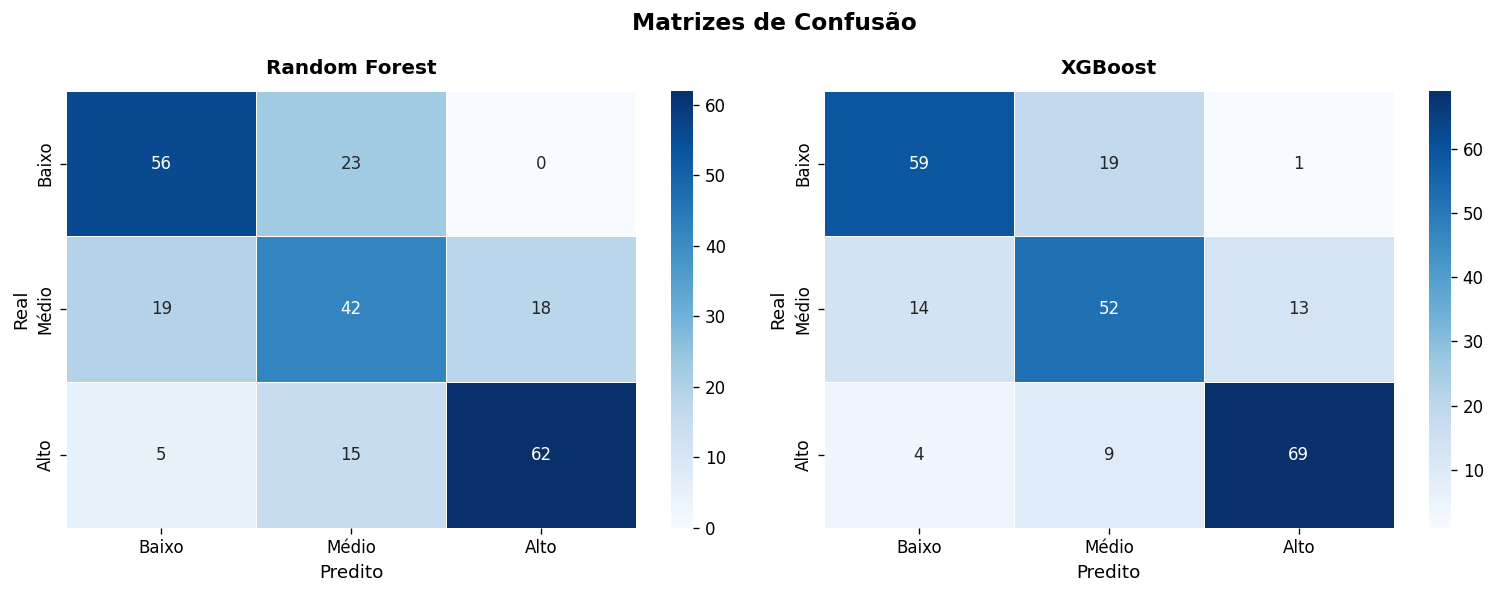

📊 Matrizes de confusão geradas.


In [12]:
# ── Matrizes de confusão ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrizes de Confusão', fontsize=14, fontweight='bold')

for ax, y_pred, titulo in [
    (ax1, y_pred_rf,  'Random Forest'),
    (ax2, y_pred_xgb, 'XGBoost')
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=nomes_classes,
        yticklabels=nomes_classes,
        linewidths=0.5, linecolor='white'
    )
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_xlabel('Predito', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print('📊 Matrizes de confusão geradas.')

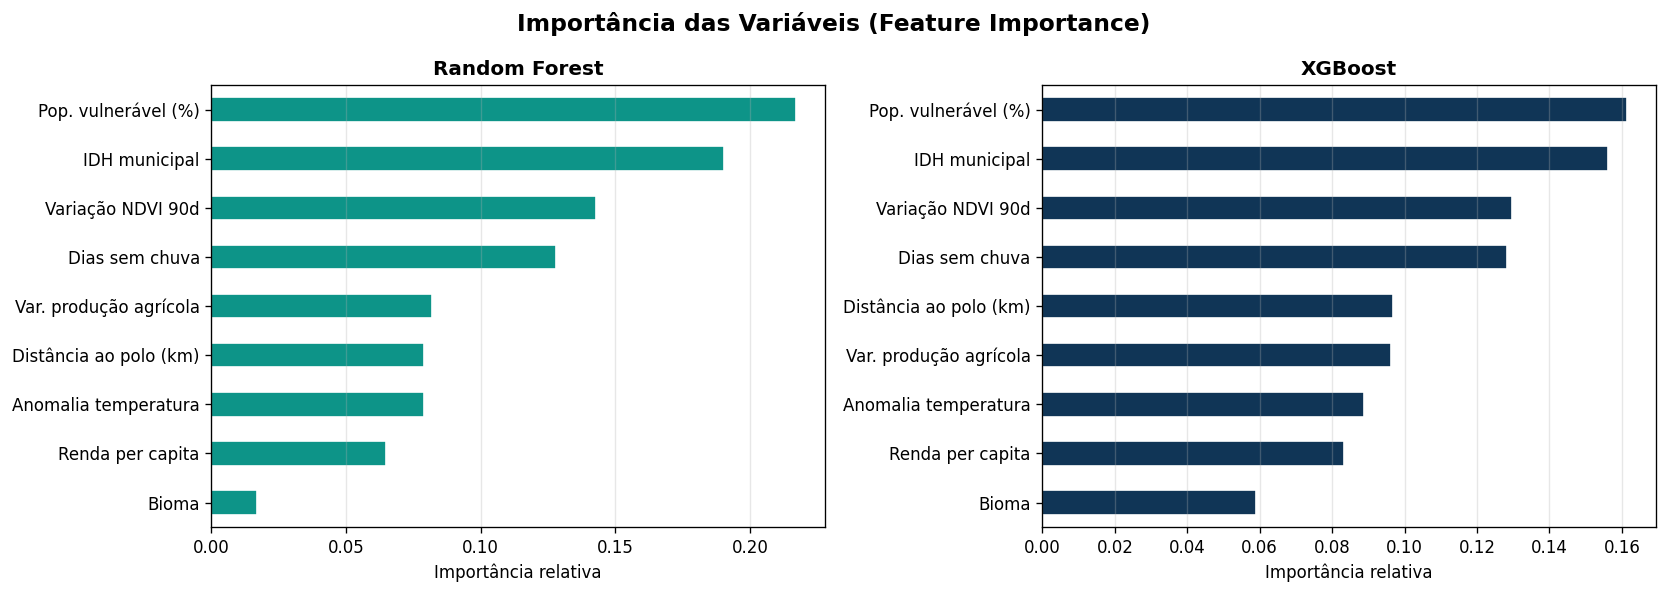

📊 Feature importance gerada.


In [13]:
# ── Feature Importance ───────────────────────────────────────────────
fi_rf  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=True)
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

nomes_legíveis = {
    'ndvi_variacao_90d':      'Variação NDVI 90d',
    'dias_sem_chuva':         'Dias sem chuva',
    'temp_anomalia':          'Anomalia temperatura',
    'producao_agricola_var':  'Var. produção agrícola',
    'idh_municipal':          'IDH municipal',
    'renda_per_capita':       'Renda per capita',
    'distancia_polo_km':      'Distância ao polo (km)',
    'bioma_enc':              'Bioma',
    'pop_vulneravel_pct':     'Pop. vulnerável (%)',
}

fi_rf.index  = [nomes_legíveis[i] for i in fi_rf.index]
fi_xgb.index = [nomes_legíveis[i] for i in fi_xgb.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Importância das Variáveis (Feature Importance)', fontsize=14, fontweight='bold')

fi_rf.plot(kind='barh', ax=ax1, color='#0D9488', edgecolor='white')
ax1.set_title('Random Forest', fontweight='bold')
ax1.set_xlabel('Importância relativa')
ax1.grid(axis='x', alpha=0.3)

fi_xgb.plot(kind='barh', ax=ax2, color='#103556', edgecolor='white')
ax2.set_title('XGBoost', fontweight='bold')
ax2.set_xlabel('Importância relativa')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('📊 Feature importance gerada.')

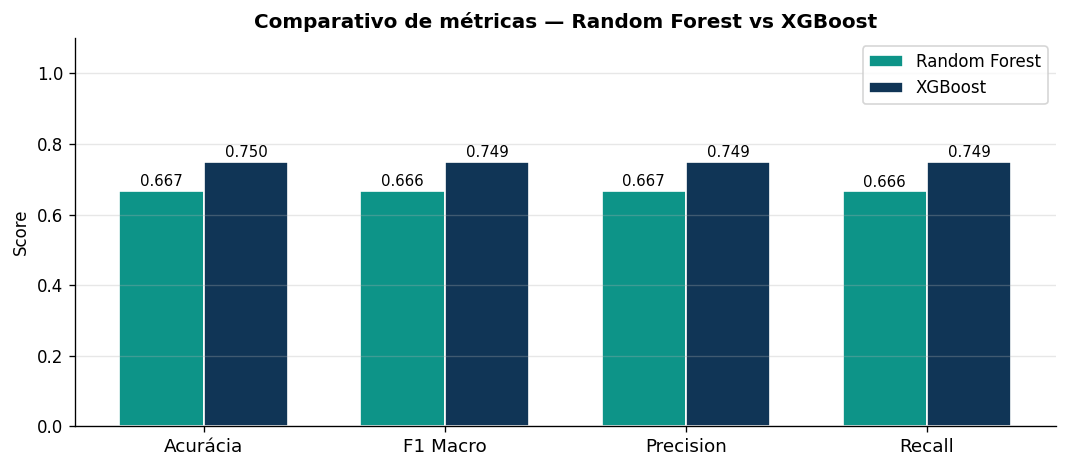


📋 Tabela de métricas:
               Acurácia  F1 Macro  Precision  Recall
Random Forest    0.6667     0.666     0.6667  0.6655
XGBoost          0.7500     0.749     0.7492  0.7488


In [14]:
# ── Comparativo de métricas entre modelos ────────────────────────────
metricas = {}
for nome, y_pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    metricas[nome] = {
        'Acurácia':  accuracy_score(y_test, y_pred),
        'F1 Macro':  f1_score(y_test, y_pred, average='macro'),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall':    recall_score(y_test, y_pred, average='macro'),
    }

df_metricas = pd.DataFrame(metricas).T

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_metricas.columns))
width = 0.35

bars1 = ax.bar(x - width/2, df_metricas.iloc[0], width, label='Random Forest', color='#0D9488', edgecolor='white')
bars2 = ax.bar(x + width/2, df_metricas.iloc[1], width, label='XGBoost',       color='#103556', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(df_metricas.columns, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparativo de métricas — Random Forest vs XGBoost', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparativo_modelos.png', bbox_inches='tight')
plt.show()

print('\n📋 Tabela de métricas:')
print(df_metricas.round(4).to_string())

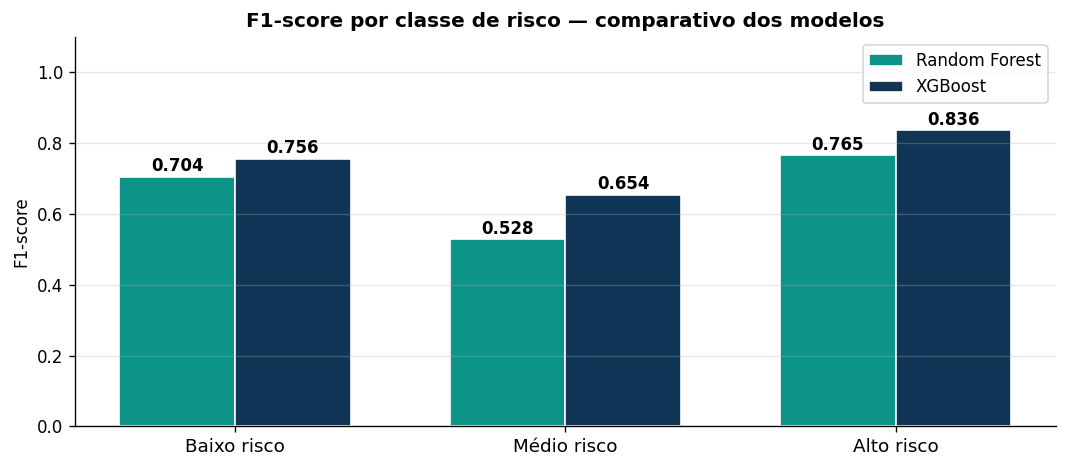

In [15]:
# ── F1-score por classe ──────────────────────────────────────────────
f1_rf  = f1_score(y_test, y_pred_rf,  average=None)
f1_xgb = f1_score(y_test, y_pred_xgb, average=None)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
width = 0.35

b1 = ax.bar(x - width/2, f1_rf,  width, label='Random Forest', color='#0D9488', edgecolor='white')
b2 = ax.bar(x + width/2, f1_xgb, width, label='XGBoost',       color='#103556', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Baixo risco', 'Médio risco', 'Alto risco'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-score')
ax.set_title('F1-score por classe de risco — comparativo dos modelos', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('f1_por_classe.png', bbox_inches='tight')
plt.show()

# 9. Análise dos Modelos e Contribuição para o Projeto

## 9.1 Justificativa da escolha dos modelos

Para este projeto foram avaliados os algoritmos Random Forest e XGBoost por serem modelos amplamente utilizados em problemas de classificação com dados tabulares. Além de apresentarem bom desempenho, ambos permitem identificar padrões complexos nos dados e gerar previsões mais consistentes.

O Random Forest foi utilizado como modelo de referência por ser mais simples de interpretar. Uma de suas vantagens é permitir a análise da importância das variáveis, ajudando a entender quais fatores tiveram maior influência na classificação dos municípios. Nos resultados obtidos, indicadores relacionados à vegetação (NDVI) e aos períodos sem chuva apareceram entre as variáveis mais relevantes para a previsão do risco alimentar.

Já o XGBoost foi utilizado como modelo principal devido à sua capacidade de melhorar progressivamente o desempenho durante o treinamento. Nos testes realizados, ele apresentou resultados superiores ao Random Forest nas principais métricas avaliadas, especialmente na identificação dos municípios classificados como alto risco.

Como o objetivo do projeto é apoiar ações preventivas, reduzir casos em que municípios vulneráveis deixam de ser identificados corretamente é um fator importante. Nesse aspecto, o XGBoost apresentou melhor desempenho e se mostrou a alternativa mais adequada para o cenário analisado.

## 9.2 Limitações do modelo

Apesar dos resultados obtidos serem promissores, este projeto apresenta algumas limitações que devem ser consideradas.

- **Dados simulados:** o conjunto de dados utilizado foi criado para representar cenários compatíveis com informações reais. Em uma aplicação prática, seria necessário utilizar dados coletados diretamente de fontes oficiais e atualizadas.

- **Ausência de séries temporais:** o modelo considera apenas os dados disponíveis no momento da análise. Trabalhar com séries temporais pode permitir uma melhor compreensão da evolução das condições climáticas ao longo do tempo.

- **Variáveis adicionais:** fatores como acesso à infraestrutura, presença de centros de distribuição de alimentos e indicadores sociais complementares poderiam enriquecer a análise e aumentar o poder preditivo do modelo.

- **Distribuição das classes:** embora o conjunto de dados tenha sido preparado para treinamento, cenários reais podem apresentar desequilíbrios mais significativos entre municípios de baixo e alto risco, exigindo técnicas específicas para tratamento desse problema.

### 9.3 Como os resultados podem apoiar a tomada de decisão

O modelo gera uma classificação de risco alimentar para cada município, dividindo-os em três categorias: **Baixo**, **Médio** e **Alto** risco. Além disso, a análise de importância das variáveis permite entender quais fatores mais influenciaram cada previsão.

Na prática, essas informações podem ser utilizadas de diferentes formas:

**Prefeituras e secretarias municipais**

- Identificar municípios que apresentam sinais de aumento do risco alimentar;
- Planejar ações preventivas com maior antecedência;
- Direcionar recursos e programas sociais para as regiões mais vulneráveis.

**Órgãos estaduais e federais**

- Apoiar a definição de prioridades para distribuição de recursos;
- Complementar análises realizadas por programas de segurança alimentar;
- Utilizar evidências baseadas em dados para apoiar decisões estratégicas.

**Pesquisadores e organizações sociais**

- Mapear regiões com maior vulnerabilidade;
- Realizar estudos sobre fatores associados à insegurança alimentar;
- Apoiar projetos e iniciativas voltados à redução do problema.

Os resultados obtidos demonstram que a combinação de dados climáticos, informações socioeconômicas e técnicas de machine learning pode contribuir para a identificação antecipada de cenários de risco, auxiliando gestores e instituições na tomada de decisões mais informadas.

In [16]:
# ── Resumo final ─────────────────────────────────────────────────────
print('=' * 60)
print('RESUMO FINAL — OrbitFood ML Pipeline')
print('=' * 60)
print(f'Dataset:           {N} municípios simulados')
print(f'Features:          {len(FEATURES)}')
print(f'Split treino/test: 80% / 20%')
print(f'Validação cruzada: 5-fold estratificada')
print()
print(f'{"Métrica":<18} {"Random Forest":>15} {"XGBoost":>12}')
print('-' * 48)
for metrica in ['Acurácia', 'F1 Macro', 'Precision', 'Recall']:
    rf_val  = metricas['Random Forest'][metrica]
    xgb_val = metricas['XGBoost'][metrica]
    melhor = '← melhor' if xgb_val >= rf_val else ''
    print(f'{metrica:<18} {rf_val:>15.4f} {xgb_val:>12.4f} {melhor}')
print('-' * 48)
print(f'{"CV F1-macro":<18} {cv_rf.mean():>15.4f} {cv_xgb.mean():>12.4f}')
print()
print('🏆 Modelo recomendado para produção: XGBoost')
print('📡 Dados: NASA EarthData · NOAA · MapBiomas · IBGE PAM')
print('🎯 ODS: 2 (Fome Zero) · 10 (Desigualdades) · 13 (Clima)')

RESUMO FINAL — OrbitFood ML Pipeline
Dataset:           1200 municípios simulados
Features:          9
Split treino/test: 80% / 20%
Validação cruzada: 5-fold estratificada

Métrica              Random Forest      XGBoost
------------------------------------------------
Acurácia                    0.6667       0.7500 ← melhor
F1 Macro                    0.6660       0.7490 ← melhor
Precision                   0.6667       0.7492 ← melhor
Recall                      0.6655       0.7488 ← melhor
------------------------------------------------
CV F1-macro                 0.7057       0.7308

🏆 Modelo recomendado para produção: XGBoost
📡 Dados: NASA EarthData · NOAA · MapBiomas · IBGE PAM
🎯 ODS: 2 (Fome Zero) · 10 (Desigualdades) · 13 (Clima)


In [25]:
import joblib

df.to_csv("municipios.csv", index=False)

joblib.dump(
    xgb,
    "modelo_orbitfood.pkl"
)

print("Arquivos salvos com sucesso")

Arquivos salvos com sucesso
